In [1]:
# region Imports

#* --------------------------------------------------------------------------------
#* General purpose imports
#* --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from scipy.stats import fisher_exact, barnard_exact
from matplotlib.ticker import FuncFormatter
import pickle as pkl


#* --------------------------------------------------------------------------------
#* Personal librairies imports
#* --------------------------------------------------------------------------------
import sys, os
src_path = os.path.abspath(os.path.join("..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils import astro_utils as au
from utils import maths_utils  as mu
from utils import stats_utils  as su
from utils import graphics_utils  as gu
from utils import labels_utils  as lu
from utils import pandas_utils  as pu


#* --------------------------------------------------------------------------------
#* Project modules imports
#* --------------------------------------------------------------------------------
import sSFR
import generate_report as report
import domination

#* --------------------------------------------------------------------------------
#* Global variables
#* --------------------------------------------------------------------------------
import config as co

#* --------------------------------------------------------------------------------
#* Project data
#* --------------------------------------------------------------------------------

with open(co.DATA_PATH + co.PROCESS_SAMPLES, "rb") as file:
            sample = pkl.load(file)



# endregion

Done


In [2]:
sample['CG4_Gals'].columns

Index(['objid', 'specobjid', 'Group', 'RA', 'Dec', 'M_r', 'Lum', 'z',
       'dist2BGG', 'lgm', 'sfr', 'sSFR', 'rank_dist', 'rank_M', 'RA_BGG',
       'Dec_BGG', 'M_BGG', 'sSFR_status', 'p_E', 'p_S', 'is_dominated',
       'morphology', 'sSFR_raw', 'sSFR_MS_offset', 'MS_res', 'sSFR_excess'],
      dtype='object')

In [3]:
sample.keys()

dict_keys(['CG4_Gals', 'Control4B_Gals', 'Control4C_Gals', 'RG4_Gals', 'CG4_Groups', 'Control4B_Groups', 'Control4C_Groups', 'RG4_Groups', 'SDSS', 'SDSS_withAGN'])

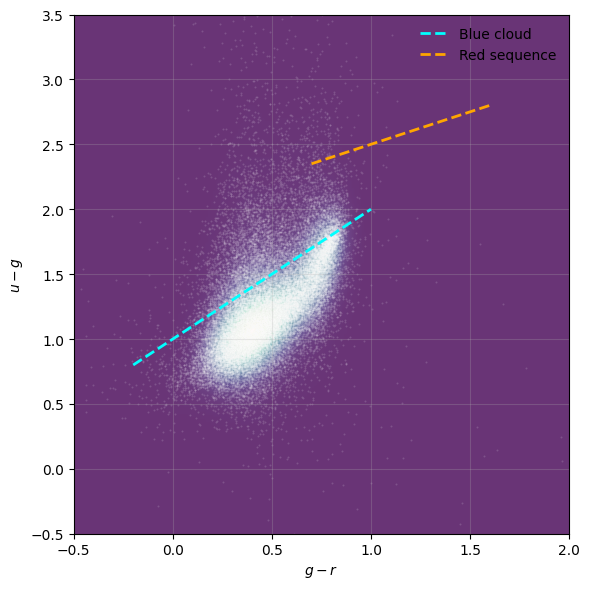

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

sdss = sample["SDSS"]

# --- Colors ---
x = sdss["g_obs"] - sdss["r_obs"]   # g − r
y = sdss["u_obs"] - sdss["g_obs"]   # u − g

# Remove NaNs / inf
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# --- KDE ---
values = np.vstack([x, y])
kde = gaussian_kde(values)

xmin, xmax = -0.5, 2.0
ymin, ymax = -0.5, 3.5

xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
grid = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid).reshape(xx.shape)

# --- Plot ---
plt.figure(figsize=(6, 6))

# Density map
plt.imshow(
    np.rot90(zz),
    extent=[xmin, xmax, ymin, ymax],
    cmap="viridis",
    aspect="auto",
    alpha=0.8
)

# Scatter (light overlay)
plt.scatter(x, y, s=2, c="white", alpha=0.15, linewidths=0)

# -------------------------------------------------
# ⭐ STANDARD OVERLAYS
# -------------------------------------------------

# # Stellar locus (approx.)
# g_r_locus = np.linspace(-0.4, 1.6, 200)
# u_g_locus = (
#     1.2 + 1.8*g_r_locus
#     - 0.8*g_r_locus**2
#     + 0.15*g_r_locus**3
# )

# plt.plot(
#     g_r_locus,
#     u_g_locus,
#     color="red",
#     linewidth=2,
#     label="Stellar locus (approx.)"
# )

# Blue cloud guide
g_r_blue = np.linspace(-0.2, 1.0, 200)
u_g_blue = 1.0 + 1.0*g_r_blue

plt.plot(
    g_r_blue,
    u_g_blue,
    linestyle="--",
    color="cyan",
    linewidth=2,
    label="Blue cloud"
)

# Red sequence guide
g_r_red = np.linspace(0.7, 1.6, 200)
u_g_red = 2.0 + 0.5*g_r_red

plt.plot(
    g_r_red,
    u_g_red,
    linestyle="--",
    color="orange",
    linewidth=2,
    label="Red sequence"
)

# -------------------------------------------------

plt.xlabel(r"$g-r$")
plt.ylabel(r"$u-g$")

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.legend(frameon=False)
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


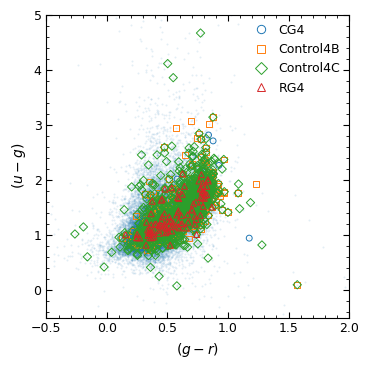

CG4_Gals: matched 110 galaxies
Control4B_Gals: matched 931 galaxies
Control4C_Gals: matched 1478 galaxies
RG4_Gals: matched 102 galaxies


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.lines import Line2D

# -----------------------------
# Helpers
# -----------------------------
def _as_int(series):
    """Robust cast for ID matching (handles uint64/int/strings with NaNs)."""
    return pd.to_numeric(series, errors="coerce").astype("Int64")

def match_subsample_to_sdss(sample, subsample_key, sdss_key="SDSS"):
    """
    Returns a merged DF for a given subsample, adding u/g/i/z observed magnitudes from SDSS
    by matching specobjid (subsample) to specObjID (SDSS).
    """
    df_sub = sample[subsample_key].copy()
    df_sdss = sample[sdss_key].copy()

    # Normalize join keys
    df_sub["_specid"]  = _as_int(df_sub["specobjid"])
    df_sdss["_specid"] = _as_int(df_sdss["specObjID"])

    # Keep only the SDSS columns we need
    cols_sdss = ["_specid", "u_obs", "g_obs", "r_obs", "i_obs", "z_obs"]
    df_sdss_small = df_sdss[cols_sdss].drop_duplicates("_specid")

    merged = df_sub.merge(df_sdss_small, on="_specid", how="inner")
    return merged

# -----------------------------
# Build colour-colour for SDSS background
# -----------------------------
df_sdss = sample["SDSS"].copy()

# Ensure numeric
for c in ["u_obs", "g_obs", "r_obs"]:
    df_sdss[c] = pd.to_numeric(df_sdss[c], errors="coerce")

df_sdss["u_g"] = df_sdss["u_obs"] - df_sdss["g_obs"]
df_sdss["g_r"] = df_sdss["g_obs"] - df_sdss["r_obs"]

# Clean: finite only
mask_sdss = np.isfinite(df_sdss["u_g"]) & np.isfinite(df_sdss["g_r"])
df_sdss_cc = df_sdss.loc[mask_sdss, ["u_g", "g_r"]]

# -----------------------------
# Match subsamples and compute colours
# -----------------------------
sub_keys = ["CG4_Gals", "Control4B_Gals", "Control4C_Gals", "RG4_Gals"]
sub_dfs = {}

for k in sub_keys:
    m = match_subsample_to_sdss(sample, k)

    # Ensure numeric
    m["u_obs"] = pd.to_numeric(m["u_obs"], errors="coerce")
    m["g_obs"] = pd.to_numeric(m["g_obs"], errors="coerce")
    m["r_obs"]      = pd.to_numeric(m["r_obs"], errors="coerce")

    # Colours
    m["u_g"] = m["u_obs"] - m["g_obs"]
    m["g_r"] = m["g_obs"] - m["r_obs"]

    m = m[np.isfinite(m["u_g"]) & np.isfinite(m["g_r"])]
    sub_dfs[k] = m

# -----------------------------
# A&A-style figure settings
# -----------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
})

fig, ax = plt.subplots(figsize=(3.54, 3.54))  # ~A&A single-column width

# SDSS background: rasterized to keep vector PDF small
ax.scatter(
    df_sdss_cc["g_r"], df_sdss_cc["u_g"],
    s=2, alpha=0.12, linewidths=0,
    rasterized=True, label="SDSS"
)

# -----------------------------
# Overlays: explicit colours + markers
# -----------------------------
markers = {
    "CG4_Gals": "o",
    "Control4B_Gals": "s",
    "Control4C_Gals": "D",
    "RG4_Gals": "^",
}

colors = {
    "CG4_Gals": "C0",
    "Control4B_Gals": "C1",
    "Control4C_Gals": "C2",
    "RG4_Gals": "C3",
}

for k in sub_keys:
    dfk = sub_dfs[k]
    ax.scatter(
        dfk["g_r"], dfk["u_g"],
        s=18,
        marker=markers[k],
        linewidths=0.7,
        facecolors="none",
        edgecolors=colors[k],
    )

# -----------------------------
# Labels, limits, ticks
# -----------------------------
ax.set_xlabel(r"$(g - r)$")   # g_obs - r_obs
ax.set_ylabel(r"$(u - g)$")   # u_obs - g_obs

# limit x and y to focus on main locus
ax.set_xlim(-0.5, 2.0)
ax.set_ylim(-0.5, 5.0)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which="both", top=True, right=True)

# -----------------------------
# Legend with proxy artists (guarantees correct open-marker rendering)
# -----------------------------
legend_handles = [
    Line2D([0], [0], marker=markers["CG4_Gals"],       color=colors["CG4_Gals"],
           markerfacecolor="none", markeredgewidth=0.7, linestyle="None", markersize=6, label="CG4"),
    Line2D([0], [0], marker=markers["Control4B_Gals"], color=colors["Control4B_Gals"],
           markerfacecolor="none", markeredgewidth=0.7, linestyle="None", markersize=6, label="Control4B"),
    Line2D([0], [0], marker=markers["Control4C_Gals"], color=colors["Control4C_Gals"],
           markerfacecolor="none", markeredgewidth=0.7, linestyle="None", markersize=6, label="Control4C"),
    Line2D([0], [0], marker=markers["RG4_Gals"],       color=colors["RG4_Gals"],
           markerfacecolor="none", markeredgewidth=0.7, linestyle="None", markersize=6, label="RG4"),
]

ax.legend(handles=legend_handles, frameon=False, loc="best", handletextpad=0.4, borderaxespad=0.3)

fig.tight_layout(pad=0.2)

# Save in publication-friendly formats
# fig.savefig("ug_gr_AA.pdf", dpi=300)
# fig.savefig("ug_gr_AA.png", dpi=300)

plt.show()

# Quick sanity prints (how many matched points)
for k in sub_keys:
    print(f"{k}: matched {len(sub_dfs[k])} galaxies")

In [6]:
for cat in ['CG4_Gals', 'Control4B_Gals', 'Control4C_Gals', 'RG4_Gals']:
    print(f"{cat}: {len(sample[cat])} galaxies, matched {len(sub_dfs[cat])} with SDSS photometry")

CG4_Gals: 248 galaxies, matched 110 with SDSS photometry
Control4B_Gals: 2792 galaxies, matched 931 with SDSS photometry
Control4C_Gals: 3004 galaxies, matched 1478 with SDSS photometry
RG4_Gals: 224 galaxies, matched 102 with SDSS photometry


## Compare colours between samples

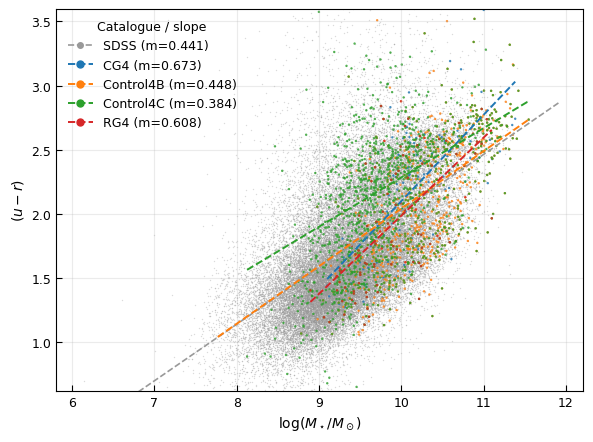

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

def _as_int(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64")

subsample_keys = ["CG4_Gals", "Control4B_Gals", "Control4C_Gals", "RG4_Gals"]
legend_order = ["SDSS", "CG4", "Control4B", "Control4C", "RG4"]
catalogue_labels = {
    "SDSS": "SDSS",
    "CG4_Gals": "CG4",
    "Control4B_Gals": "Control4B",
    "Control4C_Gals": "Control4C",
    "RG4_Gals": "RG4",
}
palette = {
    "SDSS": "0.6",
    "CG4": "C0",
    "Control4B": "C1",
    "Control4C": "C2",
    "RG4": "C3",
}

sdss = sample["SDSS"].copy()
sdss["_objid"] = _as_int(sdss["objid"])
sdss["lgm"] = pd.to_numeric(sdss["lgm"], errors="coerce")
sdss["u_r"] = pd.to_numeric(sdss["u_obs"], errors="coerce") - pd.to_numeric(sdss["r_obs"], errors="coerce")
sdss_mass_colour = sdss[["_objid", "lgm", "u_r"]].drop_duplicates("_objid")
sdss_mass_colour = sdss_mass_colour[np.isfinite(sdss_mass_colour["lgm"]) & np.isfinite(sdss_mass_colour["u_r"])].copy()
sdss_mass_colour["catalogue"] = "SDSS"

frames = [sdss_mass_colour]
for key in subsample_keys:
    sub = sample[key].copy()
    sub["_objid"] = _as_int(sub["objid"])
    sub["lgm"] = pd.to_numeric(sub["lgm"], errors="coerce")

    merged = (
        sub[["_objid", "lgm"]]
        .merge(sdss_mass_colour[["_objid", "u_r"]], on="_objid", how="inner")
        .drop_duplicates("_objid")
    )
    merged = merged[np.isfinite(merged["lgm"]) & np.isfinite(merged["u_r"])].copy()
    merged["catalogue"] = catalogue_labels[key]
    frames.append(merged)

mass_colour = pd.concat(frames, ignore_index=True)
subsample_mass_colour = mass_colour.loc[mass_colour["catalogue"] != "SDSS"].copy()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(
    sdss_mass_colour["lgm"],
    sdss_mass_colour["u_r"],
    s=1,
    color=palette["SDSS"],
    alpha=0.35,
    linewidths=0,
    rasterized=True,
)

sns.scatterplot(
    data=subsample_mass_colour,
    x="lgm",
    y="u_r",
    hue="catalogue",
    hue_order=[catalogue_labels[key] for key in subsample_keys],
    palette=palette,
    s=3,
    alpha=0.8,
    linewidth=0,
    ax=ax,
    legend=False,
)

slope_by_catalogue = {}
for label in legend_order:
    group = mass_colour.loc[mass_colour["catalogue"] == label].sort_values("lgm")
    if len(group) < 2:
        continue

    slope, intercept = np.polyfit(group["lgm"], group["u_r"], deg=1)
    slope_by_catalogue[label] = slope
    x_fit = np.linspace(group["lgm"].min(), group["lgm"].max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(
        x_fit,
        y_fit,
        linestyle="--",
        linewidth=1.2 if label == "SDSS" else 1.4,
        color=palette[label],
    )

legend_handles = [
    Line2D(
        [0], [0],
        color=palette[label],
        linestyle="--",
        linewidth=1.2 if label == "SDSS" else 1.4,
        marker="o",
        markerfacecolor=palette[label],
        markeredgecolor=palette[label],
        markersize=4 if label == "SDSS" else 5,
        label=f"{label} (m={slope_by_catalogue[label]:.3f})",
    )
    for label in legend_order
    if label in slope_by_catalogue
]

ax.set_xlabel(r"$\log(M_\star/M_\odot)$")
ax.set_ylabel(r"$(u-r)$")
ax.grid(alpha=0.25)
ax.legend(handles=legend_handles, title="Catalogue / slope", frameon=False)

# Keep the view focused on the main locus without altering the matched sample.
if len(mass_colour) > 0:
    y_lo, y_hi = mass_colour["u_r"].quantile([0.01, 0.99])
    ax.set_ylim(y_lo - 0.2, y_hi + 0.2)

plt.tight_layout()
plt.show()


In [8]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

subsample_keys = ["CG4_Gals", "Control4B_Gals", "Control4C_Gals", "RG4_Gals"]
catalogue_labels = {
    "CG4_Gals": "CG4",
    "Control4B_Gals": "Control4B",
    "Control4C_Gals": "Control4C",
    "RG4_Gals": "RG4",
}
reference_catalogue = "CG4"
comparison_catalogues = ["Control4B", "Control4C", "RG4", "SDSS"]
category_order = [reference_catalogue, *comparison_catalogues]

sdss_test = sample["SDSS"].copy()
sdss_test["_objid"] = _as_int(sdss_test["objid"])
for column in ["lgm", "u_obs", "g_obs", "r_obs", "i_obs"]:
    sdss_test[column] = pd.to_numeric(sdss_test[column], errors="coerce")

sdss_test["u_r"] = sdss_test["u_obs"] - sdss_test["r_obs"]
sdss_test["u_g"] = sdss_test["u_obs"] - sdss_test["g_obs"]
sdss_test["g_r"] = sdss_test["g_obs"] - sdss_test["r_obs"]
sdss_test["r_i"] = sdss_test["r_obs"] - sdss_test["i_obs"]

sdss_colour_test = sdss_test[["_objid", "lgm", "u_r", "u_g", "g_r", "r_i"]].drop_duplicates("_objid")
frames = [sdss_colour_test.assign(catalogue="SDSS")]

for key in subsample_keys:
    sub = sample[key].copy()
    sub["_objid"] = _as_int(sub["objid"])
    sub["lgm"] = pd.to_numeric(sub["lgm"], errors="coerce")

    merged = (
        sub[["_objid", "lgm"]]
        .merge(sdss_colour_test.drop(columns="lgm"), on="_objid", how="inner")
        .drop_duplicates("_objid")
    )
    merged["catalogue"] = catalogue_labels[key]
    frames.append(merged)

multi_colour_test = pd.concat(frames, ignore_index=True)

colour_specs = [
    ("u_r", "u-r"),
    ("u_g", "u-g"),
    ("g_r", "g-r"),
    ("r_i", "r-i"),
]

slope_rows = []
global_rows = []
pairwise_frames = []

for colour_key, colour_label in colour_specs:
    panel = multi_colour_test[np.isfinite(multi_colour_test["lgm"]) & np.isfinite(multi_colour_test[colour_key])].copy()
    panel["catalogue"] = pd.Categorical(panel["catalogue"], categories=category_order, ordered=True)

    slope_model = smf.ols(
        f'{colour_key} ~ lgm * C(catalogue, Treatment(reference="{reference_catalogue}"))',
        data=panel,
    ).fit(cov_type="HC3")

    for label, group in panel.groupby("catalogue", observed=False):
        if len(group) < 2:
            continue
        slope, intercept = np.polyfit(group["lgm"], group[colour_key], deg=1)
        slope_rows.append(
            {
                "colour": colour_label,
                "catalogue": label,
                "n": len(group),
                "slope": slope,
                "intercept": intercept,
            }
        )

    interaction_terms = [
        f'lgm:C(catalogue, Treatment(reference="{reference_catalogue}"))[T.{other}]'
        for other in comparison_catalogues
        if f'lgm:C(catalogue, Treatment(reference="{reference_catalogue}"))[T.{other}]' in slope_model.params.index
    ]
    global_test = slope_model.wald_test([f"{term} = 0" for term in interaction_terms], scalar=True)
    global_rows.append(
        {
            "colour": colour_label,
            "n_total": len(panel),
            "chi2": global_test.statistic,
            "pvalue": global_test.pvalue,
        }
    )

    pairwise_rows = []
    for other in comparison_catalogues:
        term = f'lgm:C(catalogue, Treatment(reference="{reference_catalogue}"))[T.{other}]'
        if term not in slope_model.params.index:
            continue

        delta_slope = -slope_model.params[term]  # CG4 slope minus the comparison slope
        se = slope_model.bse[term]
        test_stat = delta_slope / se
        p_two_sided = slope_model.pvalues[term]
        p_one_sided = p_two_sided / 2 if delta_slope > 0 else 1 - p_two_sided / 2
        pairwise_rows.append(
            {
                "colour": colour_label,
                "comparison": f"CG4 > {other}",
                "delta_slope": delta_slope,
                "test_stat": test_stat,
                "p_one_sided": p_one_sided,
            }
        )

    pairwise_summary = pd.DataFrame(pairwise_rows)
    _, pairwise_summary["p_holm"], _, _ = multipletests(
        pairwise_summary["p_one_sided"],
        method="holm",
    )
    pairwise_summary["significant_0.05"] = pairwise_summary["p_holm"] < 0.05
    pairwise_frames.append(pairwise_summary)

slope_summary = pd.DataFrame(slope_rows)
global_summary = pd.DataFrame(global_rows)
pairwise_summary = pd.concat(pairwise_frames, ignore_index=True)

print("Robust ANCOVA slope comparison for all four colour-mass panels.")
print("Holm correction is applied separately within each colour across the four CG4-vs-other comparisons.")
display(slope_summary.round({"slope": 4, "intercept": 4}))
display(global_summary.round({"chi2": 3, "pvalue": 4}))
display(pairwise_summary.round({"delta_slope": 4, "test_stat": 3, "p_one_sided": 4, "p_holm": 4}))

significant_summary = (
    pairwise_summary.loc[pairwise_summary["significant_0.05"], ["colour", "comparison"]]
    .groupby("colour", sort=False)["comparison"]
    .agg(lambda values: ", ".join(values))
)

if significant_summary.empty:
    print("At alpha = 0.05 with Holm correction, CG4 is not significantly steeper than the other catalogues in any panel.")
else:
    print("At alpha = 0.05 with Holm correction, CG4 is significantly steeper than:")
    for colour_label, comparisons in significant_summary.items():
        print(f"  {colour_label}: {comparisons}")


Robust ANCOVA slope comparison for all four colour-mass panels.
Holm correction is applied separately within each colour across the four CG4-vs-other comparisons.


,colour,catalogue,n,slope,intercept
0,u-r,CG4,110,0.6727,-4.6270
1,u-r,Control4B,931,0.4481,-2.4390
2,u-r,Control4C,1459,0.3840,-1.5553
3,u-r,RG4,102,0.6084,-4.0967
4,u-r,SDSS,52531,0.4407,-2.3832
5,u-g,CG4,110,0.4385,-2.9132
6,u-g,Control4B,931,0.2282,-0.8300
7,u-g,Control4C,1459,0.2014,-0.3930
8,u-g,RG4,102,0.3501,-2.0992
9,u-g,SDSS,52531,0.2526,-1.0979


,colour,n_total,chi2,pvalue
0,u-r,55133,20.016,0.0005
1,u-g,55133,16.891,0.0020
2,g-r,55133,22.694,0.0001
3,r-i,55133,14.882,0.0050


,colour,comparison,delta_slope,test_stat,p_one_sided,p_holm,significant_0.05
0,u-r,CG4 > Control4B,0.2246,1.719,0.0428,0.0857,False
1,u-r,CG4 > Control4C,0.2887,3.287,0.0005,0.0016,True
2,u-r,CG4 > RG4,0.0643,0.704,0.2408,0.2408,False
3,u-r,CG4 > SDSS,0.2320,3.348,0.0004,0.0016,True
4,u-g,CG4 > Control4B,0.2103,1.805,0.0355,0.0710,False
5,u-g,CG4 > Control4C,0.2370,3.103,0.0010,0.0029,True
6,u-g,CG4 > RG4,0.0884,1.247,0.1061,0.1061,False
7,u-g,CG4 > SDSS,0.1859,3.345,0.0004,0.0016,True
8,g-r,CG4 > Control4B,0.0143,0.577,0.2819,0.5638,False
9,g-r,CG4 > Control4C,0.0517,2.238,0.0126,0.0505,False


At alpha = 0.05 with Holm correction, CG4 is significantly steeper than:
  u-r: CG4 > Control4C, CG4 > SDSS
  u-g: CG4 > Control4C, CG4 > SDSS


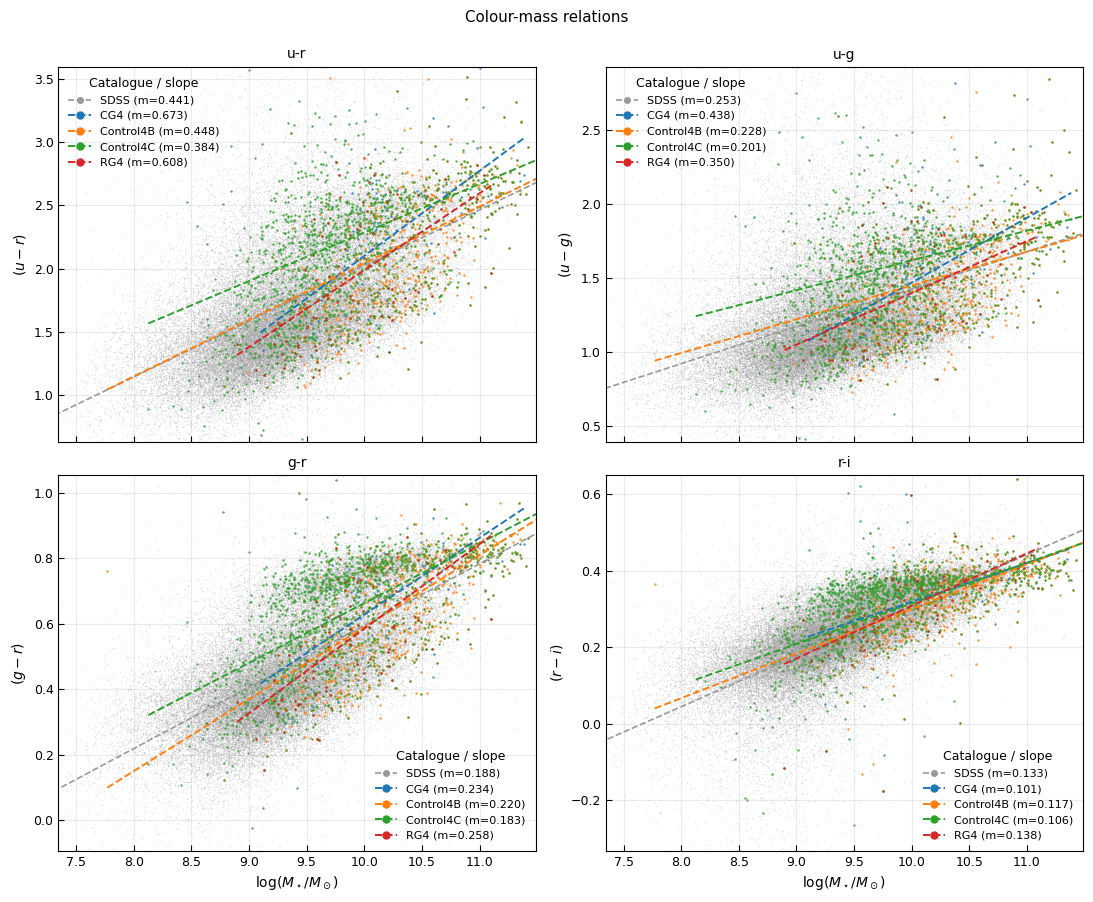

In [9]:
from matplotlib.lines import Line2D

subsample_keys = ["CG4_Gals", "Control4B_Gals", "Control4C_Gals", "RG4_Gals"]
legend_order = ["SDSS", "CG4", "Control4B", "Control4C", "RG4"]
catalogue_labels = {
    "SDSS": "SDSS",
    "CG4_Gals": "CG4",
    "Control4B_Gals": "Control4B",
    "Control4C_Gals": "Control4C",
    "RG4_Gals": "RG4",
}
palette = {
    "SDSS": "0.6",
    "CG4": "C0",
    "Control4B": "C1",
    "Control4C": "C2",
    "RG4": "C3",
}

sdss_multi = sample["SDSS"].copy()
sdss_multi["_objid"] = _as_int(sdss_multi["objid"])
for column in ["lgm", "u_obs", "g_obs", "r_obs", "i_obs"]:
    sdss_multi[column] = pd.to_numeric(sdss_multi[column], errors="coerce")

sdss_multi["u_r"] = sdss_multi["u_obs"] - sdss_multi["r_obs"]
sdss_multi["u_g"] = sdss_multi["u_obs"] - sdss_multi["g_obs"]
sdss_multi["g_r"] = sdss_multi["g_obs"] - sdss_multi["r_obs"]
sdss_multi["r_i"] = sdss_multi["r_obs"] - sdss_multi["i_obs"]

sdss_plot = sdss_multi[["_objid", "lgm", "u_r", "u_g", "g_r", "r_i"]].drop_duplicates("_objid")
frames = [sdss_plot.assign(catalogue="SDSS")]

for key in subsample_keys:
    sub = sample[key].copy()
    sub["_objid"] = _as_int(sub["objid"])
    sub["lgm"] = pd.to_numeric(sub["lgm"], errors="coerce")

    merged = (
        sub[["_objid", "lgm"]]
        .merge(sdss_plot.drop(columns="lgm"), on="_objid", how="inner")
        .drop_duplicates("_objid")
    )
    merged["catalogue"] = catalogue_labels[key]
    frames.append(merged)

multi_colour = pd.concat(frames, ignore_index=True)

# No B-band magnitude is available in the processed sample, so use u-g as the SDSS-native proxy.
colour_specs = [
    ("u_r", r"$(u-r)$", "u-r"),
    ("u_g", r"$(u-g)$", "u-g"),
    ("g_r", r"$(g-r)$", "g-r"),
    ("r_i", r"$(r-i)$", "r-i"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

for ax, (colour_key, ylabel, title) in zip(axes, colour_specs):
    panel = multi_colour[np.isfinite(multi_colour["lgm"]) & np.isfinite(multi_colour[colour_key])].copy()
    slope_by_catalogue = {}

    for label in legend_order:
        group = panel.loc[panel["catalogue"] == label].sort_values("lgm")
        if group.empty:
            continue

        ax.scatter(
            group["lgm"],
            group[colour_key],
            s=1 if label == "SDSS" else 3,
            color=palette[label],
            alpha=0.25 if label == "SDSS" else 0.8,
            linewidths=0,
            rasterized=(label == "SDSS"),
        )

        if len(group) < 2:
            continue

        slope, intercept = np.polyfit(group["lgm"], group[colour_key], deg=1)
        slope_by_catalogue[label] = slope
        x_fit = np.linspace(group["lgm"].min(), group["lgm"].max(), 100)
        ax.plot(
            x_fit,
            slope * x_fit + intercept,
            linestyle="--",
            linewidth=1.2 if label == "SDSS" else 1.4,
            color=palette[label],
        )

    legend_handles = [
        Line2D(
            [0], [0],
            color=palette[label],
            linestyle="--",
            linewidth=1.2 if label == "SDSS" else 1.4,
            marker="o",
            markerfacecolor=palette[label],
            markeredgecolor=palette[label],
            markersize=4 if label == "SDSS" else 5,
            label=f"{label} (m={slope_by_catalogue[label]:.3f})",
        )
        for label in legend_order
        if label in slope_by_catalogue
    ]

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(handles=legend_handles, title="Catalogue / slope", frameon=False, fontsize=8, title_fontsize=9)

    y_lo, y_hi = panel[colour_key].quantile([0.01, 0.99])
    ax.set_ylim(y_lo - 0.2, y_hi + 0.2)

for ax in axes[2:]:
    ax.set_xlabel(r"$\log(M_\star/M_\odot)$")

x_lo, x_hi = multi_colour["lgm"].quantile([0.001, 0.999])
for ax in axes:
    ax.set_xlim(x_lo - 0.2, x_hi + 0.2)

fig.suptitle("Colour-mass relations", y=0.995)
fig.tight_layout()
plt.show()


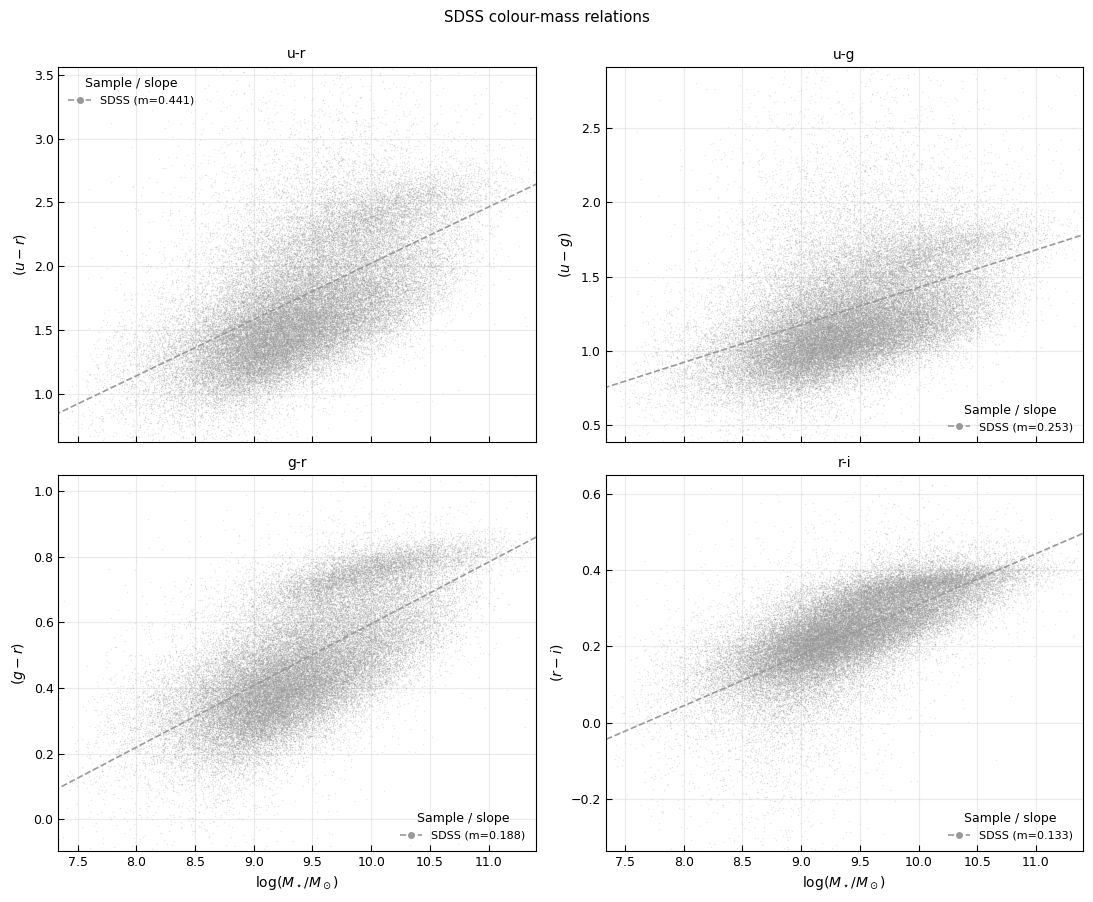

In [10]:
from matplotlib.lines import Line2D

sdss_only = sample["SDSS"].copy()
for column in ["lgm", "u_obs", "g_obs", "r_obs", "i_obs"]:
    sdss_only[column] = pd.to_numeric(sdss_only[column], errors="coerce")

sdss_only["u_r"] = sdss_only["u_obs"] - sdss_only["r_obs"]
sdss_only["u_g"] = sdss_only["u_obs"] - sdss_only["g_obs"]
sdss_only["g_r"] = sdss_only["g_obs"] - sdss_only["r_obs"]
sdss_only["r_i"] = sdss_only["r_obs"] - sdss_only["i_obs"]

# No B-band magnitude is available in the processed sample, so use u-g as the SDSS-native proxy.
colour_specs = [
    ("u_r", r"$(u-r)$", "u-r"),
    ("u_g", r"$(u-g)$", "u-g"),
    ("g_r", r"$(g-r)$", "g-r"),
    ("r_i", r"$(r-i)$", "r-i"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

for ax, (colour_key, ylabel, title) in zip(axes, colour_specs):
    panel = sdss_only[np.isfinite(sdss_only["lgm"]) & np.isfinite(sdss_only[colour_key])].copy()
    slope, intercept = np.polyfit(panel["lgm"], panel[colour_key], deg=1)
    x_fit = np.linspace(panel["lgm"].min(), panel["lgm"].max(), 100)
    y_fit = slope * x_fit + intercept

    ax.scatter(
        panel["lgm"],
        panel[colour_key],
        s=1,
        color="0.6",
        alpha=0.25,
        linewidths=0,
        rasterized=True,
    )
    ax.plot(x_fit, y_fit, linestyle="--", linewidth=1.2, color="0.6")

    legend_handle = Line2D(
        [0], [0],
        color="0.6",
        linestyle="--",
        linewidth=1.2,
        marker="o",
        markerfacecolor="0.6",
        markeredgecolor="0.6",
        markersize=4,
        label=f"SDSS (m={slope:.3f})",
    )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend(handles=[legend_handle], title="Sample / slope", frameon=False, fontsize=8, title_fontsize=9)

    y_lo, y_hi = panel[colour_key].quantile([0.01, 0.99])
    ax.set_ylim(y_lo - 0.2, y_hi + 0.2)

for ax in axes[2:]:
    ax.set_xlabel(r"$\log(M_\star/M_\odot)$")

x_lo, x_hi = sdss_only["lgm"].quantile([0.001, 0.999])
for ax in axes:
    ax.set_xlim(x_lo - 0.2, x_hi + 0.2)

fig.suptitle("SDSS colour-mass relations", y=0.995)
fig.tight_layout()
plt.show()


## Compare coulours between BGGs ans satellites

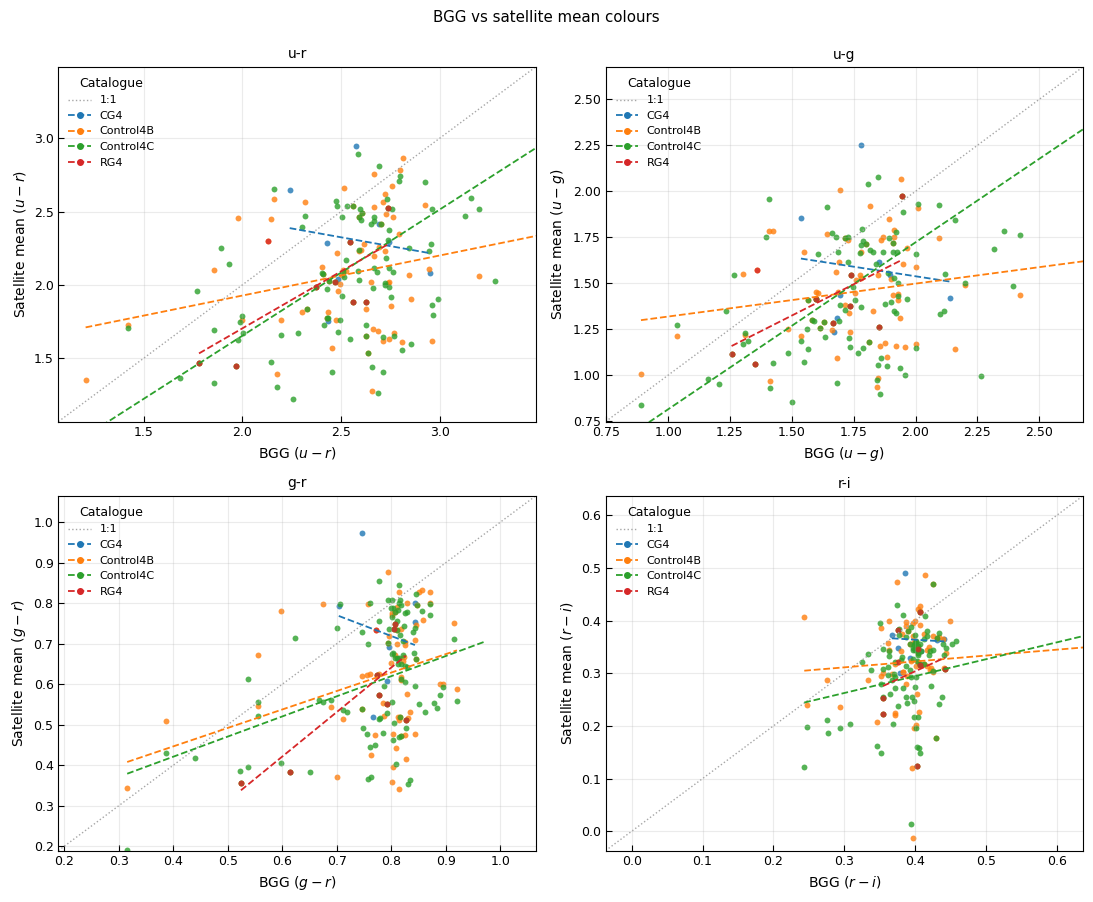

,catalogue,n_groups,mean_matched_satellites,full_satellite_matches
0,CG4,8,1.88,1
1,Control4B,76,1.71,11
2,Control4C,104,2.03,28
3,RG4,9,1.78,1


In [11]:
from scipy import stats
from matplotlib.lines import Line2D

subsample_keys = ["CG4_Gals", "Control4B_Gals", "Control4C_Gals", "RG4_Gals"]
legend_order = ["CG4", "Control4B", "Control4C", "RG4"]
sample_offsets = {"CG4": -0.09, "Control4B": -0.03, "Control4C": 0.03, "RG4": 0.09}
sample_offsets = {"CG4": -0.09, "Control4B": -0.03, "Control4C": 0.03, "RG4": 0.09}
catalogue_labels = {
    "CG4_Gals": "CG4",
    "Control4B_Gals": "Control4B",
    "Control4C_Gals": "Control4C",
    "RG4_Gals": "RG4",
}
palette = {
    "CG4": "C0",
    "Control4B": "C1",
    "Control4C": "C2",
    "RG4": "C3",
}

sdss_group = sample["SDSS"].copy()
sdss_group["_objid"] = _as_int(sdss_group["objid"])
for column in ["u_obs", "g_obs", "r_obs", "i_obs"]:
    sdss_group[column] = pd.to_numeric(sdss_group[column], errors="coerce")

sdss_group["u_r"] = sdss_group["u_obs"] - sdss_group["r_obs"]
sdss_group["u_g"] = sdss_group["u_obs"] - sdss_group["g_obs"]
sdss_group["g_r"] = sdss_group["g_obs"] - sdss_group["r_obs"]
sdss_group["r_i"] = sdss_group["r_obs"] - sdss_group["i_obs"]
sdss_group_lookup = sdss_group[["_objid", "u_r", "u_g", "g_r", "r_i"]].drop_duplicates("_objid")

group_rows = []
for key in subsample_keys:
    sub = sample[key].copy()
    sub["_objid"] = _as_int(sub["objid"])
    merged = sub[["Group", "rank_M", "_objid"]].merge(sdss_group_lookup, on="_objid", how="inner")

    for group_id, group in merged.groupby("Group"):
        bgg = group.loc[group["rank_M"] == 1]
        satellites = group.loc[group["rank_M"] > 1]
        if len(bgg) != 1 or satellites.empty:
            continue

        row = {
            "catalogue": catalogue_labels[key],
            "Group": group_id,
            "matched_members": len(group),
            "matched_satellites": len(satellites),
        }
        keep_row = True

        for colour_key in ["u_r", "u_g", "g_r", "r_i"]:
            bgg_value = pd.to_numeric(bgg[colour_key], errors="coerce").iloc[0]
            sat_values = pd.to_numeric(satellites[colour_key], errors="coerce")
            sat_values = sat_values[np.isfinite(sat_values)]
            if not np.isfinite(bgg_value) or sat_values.empty:
                keep_row = False
                break

            row[f"bgg_{colour_key}"] = float(bgg_value)
            row[f"sat_mean_{colour_key}"] = float(sat_values.mean())

        if keep_row:
            group_rows.append(row)

group_colour_pairs = pd.DataFrame(group_rows)

colour_specs = [
    ("u_r", r"$(u-r)$", "u-r"),
    ("u_g", r"$(u-g)$", "u-g"),
    ("g_r", r"$(g-r)$", "g-r"),
    ("r_i", r"$(r-i)$", "r-i"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, (colour_key, colour_label, title) in zip(axes, colour_specs):
    x_key = f"bgg_{colour_key}"
    y_key = f"sat_mean_{colour_key}"
    panel = group_colour_pairs[["catalogue", x_key, y_key]].dropna().copy()

    combined = pd.concat([panel[x_key], panel[y_key]], ignore_index=True)
    lo, hi = combined.quantile([0.01, 0.99])
    pad = 0.15
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle=":", linewidth=1.0, color="0.65")

    legend_handles = [
        Line2D([0], [0], color="0.65", linestyle=":", linewidth=1.0, label="1:1"),
    ]

    for label in legend_order:
        group = panel.loc[panel["catalogue"] == label].sort_values(x_key)
        if group.empty:
            continue

        ax.scatter(
            group[x_key],
            group[y_key],
            s=18,
            color=palette[label],
            alpha=0.8,
            linewidths=0,
        )

        if len(group) >= 2:
            slope, intercept = np.polyfit(group[x_key], group[y_key], deg=1)
            x_fit = np.linspace(group[x_key].min(), group[x_key].max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, linestyle="--", linewidth=1.3, color=palette[label])

        legend_handles.append(
            Line2D(
                [0], [0],
                color=palette[label],
                linestyle="--",
                linewidth=1.3,
                marker="o",
                markerfacecolor=palette[label],
                markeredgecolor=palette[label],
                markersize=4,
                label=label,
            )
        )

    ax.set_title(title)
    ax.set_xlabel(f"BGG {colour_label}")
    ax.set_ylabel(f"Satellite mean {colour_label}")
    ax.grid(alpha=0.25)
    ax.legend(handles=legend_handles, title="Catalogue", frameon=False, fontsize=8, title_fontsize=9)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)

fig.suptitle("BGG vs satellite mean colours", y=0.995)
fig.tight_layout()
plt.show()

# The satellite colour is the mean over the satellites matched to SDSS in each group.
display(
    group_colour_pairs.groupby("catalogue", sort=False)
    .agg(
        n_groups=("Group", "size"),
        mean_matched_satellites=("matched_satellites", "mean"),
        full_satellite_matches=("matched_satellites", lambda values: int((values == 3).sum())),
    )
    .reset_index()
    .round({"mean_matched_satellites": 2})
)


In [12]:
from scipy import stats

colour_specs = [
    ("u_r", "u-r"),
    ("u_g", "u-g"),
    ("g_r", "g-r"),
    ("r_i", "r-i"),
]

correlation_rows = []
for colour_key, colour_label in colour_specs:
    x_key = f"bgg_{colour_key}"
    y_key = f"sat_mean_{colour_key}"

    for sample_label, frame in [("All", group_colour_pairs)] + [
        (label, group_colour_pairs.loc[group_colour_pairs["catalogue"] == label])
        for label in ["CG4", "Control4B", "Control4C", "RG4"]
    ]:
        panel = frame[[x_key, y_key, "matched_satellites"]].dropna().copy()
        if len(panel) < 3:
            continue

        pearson = stats.pearsonr(panel[x_key], panel[y_key])
        spearman = stats.spearmanr(panel[x_key], panel[y_key])
        slope, intercept = np.polyfit(panel[x_key], panel[y_key], deg=1)

        correlation_rows.append(
            {
                "colour": colour_label,
                "sample": sample_label,
                "n_groups": len(panel),
                "mean_matched_satellites": panel["matched_satellites"].mean(),
                "pearson_r": pearson.statistic,
                "pearson_p": pearson.pvalue,
                "spearman_rho": spearman.statistic,
                "spearman_p": spearman.pvalue,
                "slope": slope,
                "intercept": intercept,
            }
        )

correlation_summary = pd.DataFrame(correlation_rows)
overall_summary = correlation_summary.loc[correlation_summary["sample"] == "All"].copy()
by_catalogue_summary = correlation_summary.loc[correlation_summary["sample"] != "All"].copy()

print("Pearson and Spearman correlations between the BGG colour and the mean satellite colour in each group.")
display(
    overall_summary.round(
        {
            "mean_matched_satellites": 2,
            "pearson_r": 4,
            "pearson_p": 4,
            "spearman_rho": 4,
            "spearman_p": 4,
            "slope": 4,
            "intercept": 4,
        }
    )
)
display(
    by_catalogue_summary.round(
        {
            "mean_matched_satellites": 2,
            "pearson_r": 4,
            "pearson_p": 4,
            "spearman_rho": 4,
            "spearman_p": 4,
            "slope": 4,
            "intercept": 4,
        }
    )
)

alpha = 0.05
for method_label, p_col in [("Pearson", "pearson_p"), ("Spearman", "spearman_p")]:
    significant_rows = correlation_summary.loc[correlation_summary[p_col] < alpha, ["sample", "colour"]]
    if significant_rows.empty:
        print(f"At alpha = {alpha:.2f}, no statistically significant {method_label.lower()} correlations were found.")
        continue

    summary = significant_rows.groupby("sample", sort=False)["colour"].agg(lambda values: ", ".join(values))
    pieces = [f"{sample}: {colours}" for sample, colours in summary.items()]
    print(
        f"At alpha = {alpha:.2f}, statistically significant {method_label.lower()} correlations are: "
        + "; ".join(pieces)
    )


Pearson and Spearman correlations between the BGG colour and the mean satellite colour in each group.


,colour,sample,n_groups,mean_matched_satellites,pearson_r,pearson_p,spearman_rho,spearman_p,slope,intercept
0,u-r,All,197,1.89,0.3604,0.0000,0.3207,0.0000,0.6337,0.498
5,u-g,All,197,1.89,0.3257,0.0000,0.3247,0.0000,0.6252,0.389
10,g-r,All,197,1.89,0.3405,0.0000,0.2828,0.0001,0.5070,0.222
15,r-i,All,197,1.89,0.1421,0.0464,0.2321,0.0010,0.2540,0.207


,colour,sample,n_groups,mean_matched_satellites,pearson_r,pearson_p,spearman_rho,spearman_p,slope,intercept
1,u-r,CG4,8,1.88,-0.1436,0.7345,-0.0238,0.9554,-0.2405,2.9263
2,u-r,Control4B,76,1.71,0.2514,0.0285,0.2029,0.0788,0.2732,1.3808
3,u-r,Control4C,104,2.03,0.4108,0.0000,0.4001,0.0000,0.8606,-0.0683
4,u-r,RG4,9,1.78,0.6926,0.0387,0.4667,0.2054,0.7769,0.1495
6,u-g,CG4,8,1.88,-0.1150,0.7863,0.0952,0.8225,-0.2080,1.9538
7,u-g,Control4B,76,1.71,0.1847,0.1102,0.1883,0.1033,0.1791,1.1397
8,u-g,Control4C,104,2.03,0.3868,0.0000,0.4030,0.0000,0.9081,-0.0938
9,u-g,RG4,9,1.78,0.5928,0.0925,0.5167,0.1544,0.6805,0.3034
11,g-r,CG4,8,1.88,-0.1784,0.6725,-0.0476,0.9108,-0.5140,1.1299
12,g-r,Control4B,76,1.71,0.3307,0.0035,0.2676,0.0194,0.4556,0.2641


At alpha = 0.05, statistically significant pearson correlations are: All: u-r, u-g, g-r, r-i; Control4B: u-r, g-r; Control4C: u-r, u-g, g-r; RG4: u-r, g-r
At alpha = 0.05, statistically significant spearman correlations are: All: u-r, u-g, g-r, r-i; Control4C: u-r, u-g, g-r, r-i; Control4B: g-r


In [13]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

comparison_catalogues = ["Control4B", "Control4C", "RG4"]
colour_specs = [
    ("u_r", "u-r"),
    ("u_g", "u-g"),
    ("g_r", "g-r"),
    ("r_i", "r-i"),
]
alpha = 0.05

print("Slope differences between CG4 and the control samples (Control4B, Control4C, RG4)")
print("Test: HC3-robust ANCOVA with Holm-adjusted p-values within each colour.")

slope_test_rows = []
for colour_key, colour_label in colour_specs:
    x_key = f"bgg_{colour_key}"
    y_key = f"sat_mean_{colour_key}"

    panel = group_colour_pairs.loc[
        group_colour_pairs["catalogue"].isin(["CG4", *comparison_catalogues]),
        ["catalogue", x_key, y_key],
    ].dropna().copy()
    panel["catalogue"] = pd.Categorical(
        panel["catalogue"],
        categories=["CG4", *comparison_catalogues],
        ordered=True,
    )

    slope_model = smf.ols(
        f'{y_key} ~ {x_key} * C(catalogue, Treatment(reference="CG4"))',
        data=panel,
    ).fit(cov_type="HC3")

    cg4_panel = panel.loc[panel["catalogue"] == "CG4"]
    cg4_slope = slope_model.params[x_key]

    p_values = []
    colour_rows = []
    for label in comparison_catalogues:
        comparison_panel = panel.loc[panel["catalogue"] == label]
        interaction_term = f'{x_key}:C(catalogue, Treatment(reference="CG4"))[T.{label}]'
        delta_slope = slope_model.params[interaction_term]
        comparison_slope = cg4_slope + delta_slope
        p_raw = slope_model.pvalues[interaction_term]
        p_values.append(p_raw)
        colour_rows.append(
            {
                "colour": colour_label,
                "comparison": label,
                "cg4_n": len(cg4_panel),
                "comparison_n": len(comparison_panel),
                "cg4_slope": cg4_slope,
                "comparison_slope": comparison_slope,
                "delta_slope": delta_slope,
                "p_raw": p_raw,
            }
        )

    p_holm = multipletests(p_values, method="holm")[1]
    print(f"\n{colour_label}")
    print(f"  CG4: slope = {cg4_slope:.4f} (n = {len(cg4_panel)})")

    for row, p_adj in zip(colour_rows, p_holm):
        row["p_holm"] = p_adj
        row["significant_0.05"] = p_adj < alpha
        slope_test_rows.append(row)
        significance_label = "significant" if p_adj < alpha else "not significant"
        print(
            f"  {row['comparison']}: slope = {row['comparison_slope']:.4f} "
            f"(n = {row['comparison_n']}), Δslope = {row['delta_slope']:.4f}, "
            f"p = {p_adj:.4g} ({significance_label})"
        )

slope_test_summary = pd.DataFrame(slope_test_rows)
display(
    slope_test_summary.round(
        {
            "cg4_slope": 4,
            "comparison_slope": 4,
            "delta_slope": 4,
            "p_raw": 4,
            "p_holm": 4,
        }
    )
)


Slope differences between CG4 and the control samples (Control4B, Control4C, RG4)
Test: HC3-robust ANCOVA with Holm-adjusted p-values within each colour.

u-r
  CG4: slope = -0.2405 (n = 8)
  Control4B: slope = 0.2732 (n = 76), Δslope = 0.5137, p = 0.4242 (not significant)
  Control4C: slope = 0.8606 (n = 104), Δslope = 1.1011, p = 0.358 (not significant)
  RG4: slope = 0.7769 (n = 9), Δslope = 1.0174, p = 0.358 (not significant)

u-g
  CG4: slope = -0.2080 (n = 8)
  Control4B: slope = 0.1791 (n = 76), Δslope = 0.3870, p = 0.5433 (not significant)
  Control4C: slope = 0.9081 (n = 104), Δslope = 1.1161, p = 0.4386 (not significant)
  RG4: slope = 0.6805 (n = 9), Δslope = 0.8884, p = 0.5433 (not significant)

g-r
  CG4: slope = -0.5140 (n = 8)
  Control4B: slope = 0.4556 (n = 76), Δslope = 0.9696, p = 0.7085 (not significant)
  Control4C: slope = 0.4970 (n = 104), Δslope = 1.0110, p = 0.7085 (not significant)
  RG4: slope = 1.0986 (n = 9), Δslope = 1.6126, p = 0.4443 (not significant)

r

,colour,comparison,cg4_n,comparison_n,cg4_slope,comparison_slope,delta_slope,p_raw,p_holm,significant_0.05
0,u-r,Control4B,8,76,-0.2405,0.2732,0.5137,0.4242,0.4242,False
1,u-r,Control4C,8,104,-0.2405,0.8606,1.1011,0.1193,0.3580,False
2,u-r,RG4,8,9,-0.2405,0.7769,1.0174,0.1493,0.3580,False
3,u-g,Control4B,8,76,-0.2080,0.1791,0.3870,0.5390,0.5433,False
4,u-g,Control4C,8,104,-0.2080,0.9081,1.1161,0.1462,0.4386,False
5,u-g,RG4,8,9,-0.2080,0.6805,0.8884,0.2716,0.5433,False
6,g-r,Control4B,8,76,-0.5140,0.4556,0.9696,0.3708,0.7085,False
7,g-r,Control4C,8,104,-0.5140,0.4970,1.0110,0.3542,0.7085,False
8,g-r,RG4,8,9,-0.5140,1.0986,1.6126,0.1481,0.4443,False
9,r-i,Control4B,8,76,-0.0798,0.1120,0.1918,0.7348,1.0000,False


In [14]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

subsample_keys = ["CG4_Gals", "Control4B_Gals", "Control4C_Gals", "RG4_Gals"]
catalogue_labels = {
    "CG4_Gals": "CG4",
    "Control4B_Gals": "Control4B",
    "Control4C_Gals": "Control4C",
    "RG4_Gals": "RG4",
}
colour_specs = [
    ("u_r", "u-r"),
    ("u_g", "u-g"),
    ("g_r", "g-r"),
    ("r_i", "r-i"),
]
alpha = 0.05

sdss_satellite = sample["SDSS"].copy()
sdss_satellite["_objid"] = _as_int(sdss_satellite["objid"])
for column in ["u_obs", "g_obs", "r_obs", "i_obs"]:
    sdss_satellite[column] = pd.to_numeric(sdss_satellite[column], errors="coerce")

sdss_satellite["u_r"] = sdss_satellite["u_obs"] - sdss_satellite["r_obs"]
sdss_satellite["u_g"] = sdss_satellite["u_obs"] - sdss_satellite["g_obs"]
sdss_satellite["g_r"] = sdss_satellite["g_obs"] - sdss_satellite["r_obs"]
sdss_satellite["r_i"] = sdss_satellite["r_obs"] - sdss_satellite["i_obs"]
sdss_satellite_lookup = sdss_satellite[["_objid", "u_r", "u_g", "g_r", "r_i"]].drop_duplicates("_objid")

satellite_frames = []
for key in subsample_keys:
    sub = sample[key].copy()
    sub["_objid"] = _as_int(sub["objid"])
    sub["lgm"] = pd.to_numeric(sub["lgm"], errors="coerce")

    merged = sub[["Group", "rank_M", "lgm", "_objid"]].merge(sdss_satellite_lookup, on="_objid", how="inner")
    merged = merged.loc[(merged["rank_M"] > 1) & np.isfinite(merged["lgm"])].copy()
    merged["catalogue"] = catalogue_labels[key]
    merged["environment"] = "Compact" if catalogue_labels[key] == "CG4" else "Ordinary"
    merged["cluster_id"] = merged["catalogue"] + "_" + merged["Group"].astype(str)
    satellite_frames.append(merged)

satellite_mass_colour = pd.concat(satellite_frames, ignore_index=True)
reference_mass = satellite_mass_colour["lgm"].median()

result_rows = []
for colour_key, colour_label in colour_specs:
    panel = satellite_mass_colour[["environment", "cluster_id", "lgm", colour_key]].dropna().copy()
    panel["environment"] = pd.Categorical(
        panel["environment"],
        categories=["Ordinary", "Compact"],
        ordered=True,
    )

    model = smf.ols(
        f'{colour_key} ~ lgm * C(environment, Treatment(reference="Ordinary"))',
        data=panel,
    ).fit(cov_type="cluster", cov_kwds={"groups": panel["cluster_id"]})

    offset_term = 'C(environment, Treatment(reference="Ordinary"))[T.Compact]'
    interaction_term = 'lgm:C(environment, Treatment(reference="Ordinary"))[T.Compact]'

    ordinary_slope = model.params["lgm"]
    compact_slope = ordinary_slope + model.params[interaction_term]
    interaction_p_raw = float(model.pvalues[interaction_term])
    compact_minus_ordinary = float(model.params[offset_term] + reference_mass * model.params[interaction_term])
    diff_test = model.t_test(f'{offset_term} + {reference_mass:.12f} * {interaction_term} = 0')
    diff_p_raw = float(np.asarray(diff_test.pvalue).item())

    result_rows.append(
        {
            "colour": colour_label,
            "ordinary_slope": ordinary_slope,
            "compact_slope": compact_slope,
            "compact_minus_ordinary_at_ref_mass": compact_minus_ordinary,
            "interaction_p_raw": interaction_p_raw,
            "difference_p_raw": diff_p_raw,
            "n_compact_satellites": int((panel["environment"] == "Compact").sum()),
            "n_ordinary_satellites": int((panel["environment"] == "Ordinary").sum()),
        }
    )

satellite_colour_summary = pd.DataFrame(result_rows)
satellite_colour_summary["interaction_p_holm"] = multipletests(
    satellite_colour_summary["interaction_p_raw"],
    method="holm",
)[1]
satellite_colour_summary["difference_p_holm"] = multipletests(
    satellite_colour_summary["difference_p_raw"],
    method="holm",
)[1]
satellite_colour_summary["interaction_significant_0.05"] = satellite_colour_summary["interaction_p_holm"] < alpha
satellite_colour_summary["difference_significant_0.05"] = satellite_colour_summary["difference_p_holm"] < alpha

print("Compact-group satellites versus ordinary-group satellites at fixed stellar mass")
print("Ordinary groups pool Control4B, Control4C, and RG4.")
print("Model: colour ~ lgm * environment with SE clustered by group.")
print(f"Reported colour offset is Compact - Ordinary at lgm = {reference_mass:.3f}.")

for _, row in satellite_colour_summary.iterrows():
    interaction_label = "significant" if row["interaction_significant_0.05"] else "not significant"
    difference_label = "significant" if row["difference_significant_0.05"] else "not significant"
    if row["compact_minus_ordinary_at_ref_mass"] > 0:
        direction = "redder"
    elif row["compact_minus_ordinary_at_ref_mass"] < 0:
        direction = "bluer"
    else:
        direction = "unchanged"

    print(f"\n{row['colour']}")
    print(f"  Ordinary slope: {row['ordinary_slope']:.4f}")
    print(f"  Compact slope: {row['compact_slope']:.4f}")
    print(
        f"  Mass-dependence difference: p = {row['interaction_p_holm']:.4g} "
        f"({interaction_label})"
    )
    print(
        f"  Compact - Ordinary at lgm = {reference_mass:.3f}: "
        f"{row['compact_minus_ordinary_at_ref_mass']:+.4f} mag ({direction}), "
        f"p = {row['difference_p_holm']:.4g} ({difference_label})"
    )

display(
    satellite_colour_summary.round(
        {
            "ordinary_slope": 4,
            "compact_slope": 4,
            "compact_minus_ordinary_at_ref_mass": 4,
            "interaction_p_raw": 4,
            "interaction_p_holm": 4,
            "difference_p_raw": 4,
            "difference_p_holm": 4,
        }
    )
)


Compact-group satellites versus ordinary-group satellites at fixed stellar mass
Ordinary groups pool Control4B, Control4C, and RG4.
Model: colour ~ lgm * environment with SE clustered by group.
Reported colour offset is Compact - Ordinary at lgm = 9.885.

u-r
  Ordinary slope: 0.3444
  Compact slope: 0.8188
  Mass-dependence difference: p = 2.205e-05 (significant)
  Compact - Ordinary at lgm = 9.885: -0.1244 mag (bluer), p = 0.009085 (significant)

u-g
  Ordinary slope: 0.1498
  Compact slope: 0.5322
  Mass-dependence difference: p = 0.0001424 (significant)
  Compact - Ordinary at lgm = 9.885: -0.1064 mag (bluer), p = 0.007374 (significant)

g-r
  Ordinary slope: 0.1946
  Compact slope: 0.2867
  Mass-dependence difference: p = 0.0002896 (significant)
  Compact - Ordinary at lgm = 9.885: -0.0179 mag (bluer), p = 0.4323 (not significant)

r-i
  Ordinary slope: 0.1182
  Compact slope: 0.1196
  Mass-dependence difference: p = 0.9366 (not significant)
  Compact - Ordinary at lgm = 9.885: +0

,colour,ordinary_slope,compact_slope,compact_minus_ordinary_at_ref_mass,interaction_p_raw,difference_p_raw,n_compact_satellites,n_ordinary_satellites,interaction_p_holm,difference_p_holm,interaction_significant_0.05,difference_significant_0.05
0,u-r,0.3444,0.8188,-0.1244,0.0000,0.0030,102,2273,0.0000,0.0091,True,True
1,u-g,0.1498,0.5322,-0.1064,0.0000,0.0018,102,2273,0.0001,0.0074,True,True
2,g-r,0.1946,0.2867,-0.0179,0.0001,0.2162,102,2273,0.0003,0.4323,True,False
3,r-i,0.1182,0.1196,0.0071,0.9366,0.4053,102,2273,0.9366,0.4323,False,False


## Compare coulours between satellites

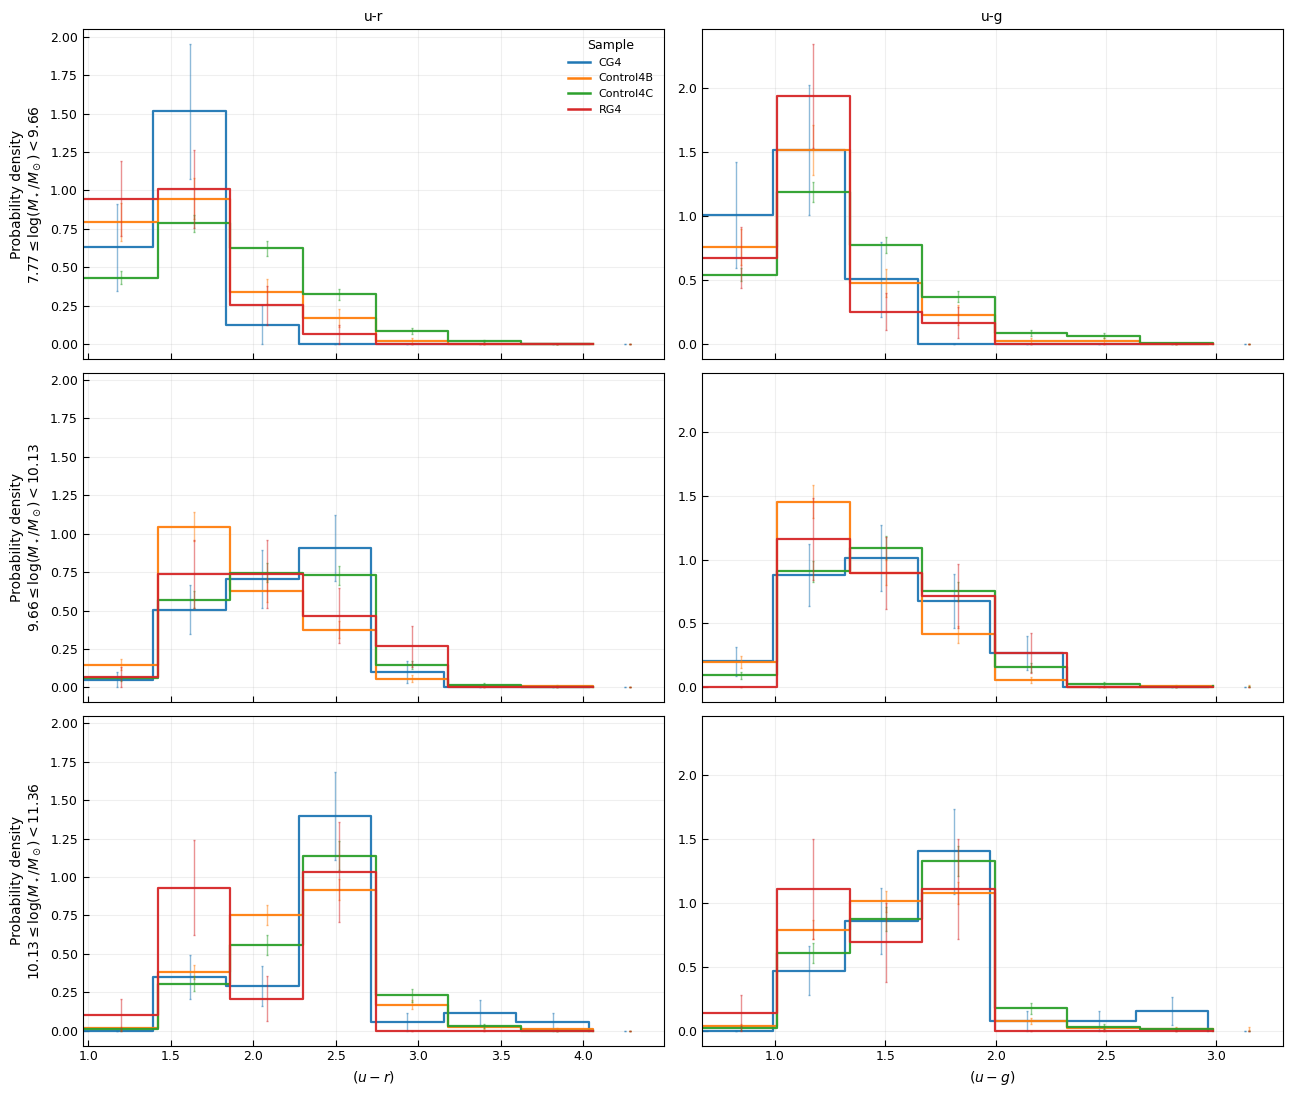

Rows are stellar-mass terciles; each panel overlays CG4, Control4B, Control4C, and RG4.
The error bars come from Poisson counting statistics in each histogram bin, rescaled to the plotted density.
A small horizontal offset is added to each sample so nearly identical curves do not sit exactly on top of one another.


In [22]:
from matplotlib.lines import Line2D

if "satellite_mass_colour" not in globals():
    subsample_keys = ["CG4_Gals", "Control4B_Gals", "Control4C_Gals", "RG4_Gals"]
    catalogue_labels = {
        "CG4_Gals": "CG4",
        "Control4B_Gals": "Control4B",
        "Control4C_Gals": "Control4C",
        "RG4_Gals": "RG4",
    }

    sdss_satellite = sample["SDSS"].copy()
    sdss_satellite["_objid"] = _as_int(sdss_satellite["objid"])
    for column in ["u_obs", "g_obs", "r_obs", "i_obs"]:
        sdss_satellite[column] = pd.to_numeric(sdss_satellite[column], errors="coerce")

    sdss_satellite["u_r"] = sdss_satellite["u_obs"] - sdss_satellite["r_obs"]
    sdss_satellite["u_g"] = sdss_satellite["u_obs"] - sdss_satellite["g_obs"]
    sdss_satellite["g_r"] = sdss_satellite["g_obs"] - sdss_satellite["r_obs"]
    sdss_satellite["r_i"] = sdss_satellite["r_obs"] - sdss_satellite["i_obs"]
    sdss_satellite_lookup = sdss_satellite[["_objid", "u_r", "u_g", "g_r", "r_i"]].drop_duplicates("_objid")

    satellite_frames = []
    for key in subsample_keys:
        sub = sample[key].copy()
        sub["_objid"] = _as_int(sub["objid"])
        sub["lgm"] = pd.to_numeric(sub["lgm"], errors="coerce")
        merged = sub[["Group", "rank_M", "lgm", "_objid"]].merge(sdss_satellite_lookup, on="_objid", how="inner")
        merged = merged.loc[(merged["rank_M"] > 1) & np.isfinite(merged["lgm"])].copy()
        merged["catalogue"] = catalogue_labels[key]
        satellite_frames.append(merged)

    satellite_mass_colour = pd.concat(satellite_frames, ignore_index=True)

palette = {
    "CG4": "C0",
    "Control4B": "C1",
    "Control4C": "C2",
    "RG4": "C3",
}
legend_order = ["CG4", "Control4B", "Control4C", "RG4"]
colour_specs = [
    ("u_r", r"$(u-r)$", "u-r"),
    ("u_g", r"$(u-g)$", "u-g"),
]

satellite_alt = satellite_mass_colour.copy()
satellite_alt["mass_bin"] = pd.qcut(satellite_alt["lgm"], q=3, duplicates="drop")
mass_categories = satellite_alt["mass_bin"].cat.categories
mass_labels = [rf"${interval.left:.2f} \leq \log(M_\star/M_\odot) < {interval.right:.2f}$" for interval in mass_categories]

fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex="col", sharey="col")

for row_index, (mass_bin, mass_label) in enumerate(zip(mass_categories, mass_labels)):
    row_data = satellite_alt.loc[satellite_alt["mass_bin"] == mass_bin].copy()

    for col_index, (colour_key, colour_axis_label, panel_title) in enumerate(colour_specs):
        ax = axes[row_index, col_index]
        panel = row_data[np.isfinite(row_data[colour_key])].copy()
        lo, hi = satellite_alt[colour_key].quantile([0.01, 0.99])
        colour_bins = np.linspace(lo - 0.1, hi + 0.1, 9)
        bin_centers = 0.5 * (colour_bins[1:] + colour_bins[:-1])
        bin_width = colour_bins[1] - colour_bins[0]

        for sample_label in legend_order:
            subset = panel.loc[panel["catalogue"] == sample_label, colour_key].dropna()
            if subset.empty:
                continue

            counts, _ = np.histogram(subset, bins=colour_bins)
            density = counts / (counts.sum() * bin_width)
            errors = np.sqrt(counts) / (counts.sum() * bin_width)
            x_offset = sample_offsets[sample_label] * bin_width

            ax.step(
                colour_bins[:-1] + x_offset,
                density,
                where="post",
                color=palette[sample_label],
                linewidth=1.6,
                alpha=0.95,
            )
            ax.errorbar(
                bin_centers + x_offset,
                density,
                yerr=errors,
                fmt="none",
                ecolor=palette[sample_label],
                alpha=0.5,
                elinewidth=1.0,
                capsize=1.0,
            )

        if row_index == 0:
            ax.set_title(panel_title)
        if col_index == 0:
            ax.set_ylabel(f"Probability density\n{mass_label}")
        if row_index == len(mass_categories) - 1:
            ax.set_xlabel(colour_axis_label)

        ax.grid(alpha=0.2, axis="both")
        ax.set_xlim(colour_bins[0], colour_bins[-1])

sample_handles = [
    Line2D([0], [0], color=palette[label], linewidth=1.8, label=label)
    for label in legend_order
]
axes[0, 0].legend(handles=sample_handles, title="Sample", frameon=False, fontsize=8, title_fontsize=9, loc="upper right")

# fig.suptitle("Satellite colour histograms: all four samples in each mass bin", y=0.995)
# fig.text(
#     0.5,
#     0.01,
#     "Rows are stellar-mass terciles, columns are u-r and u-g. Histograms are unfilled and normalized to unit area within each sample and mass bin. Error bars are Poisson uncertainties converted to density: sigma = sqrt(N) / (N_total * bin width). Small horizontal offsets are added so overlapping curves remain visible.",
#     ha="center",
#     fontsize=9,
# )
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

print("Rows are stellar-mass terciles; each panel overlays CG4, Control4B, Control4C, and RG4.")
print("The error bars come from Poisson counting statistics in each histogram bin, rescaled to the plotted density.")
print("A small horizontal offset is added to each sample so nearly identical curves do not sit exactly on top of one another.")


## Compare BGGs colour between dominated and non dominated groups

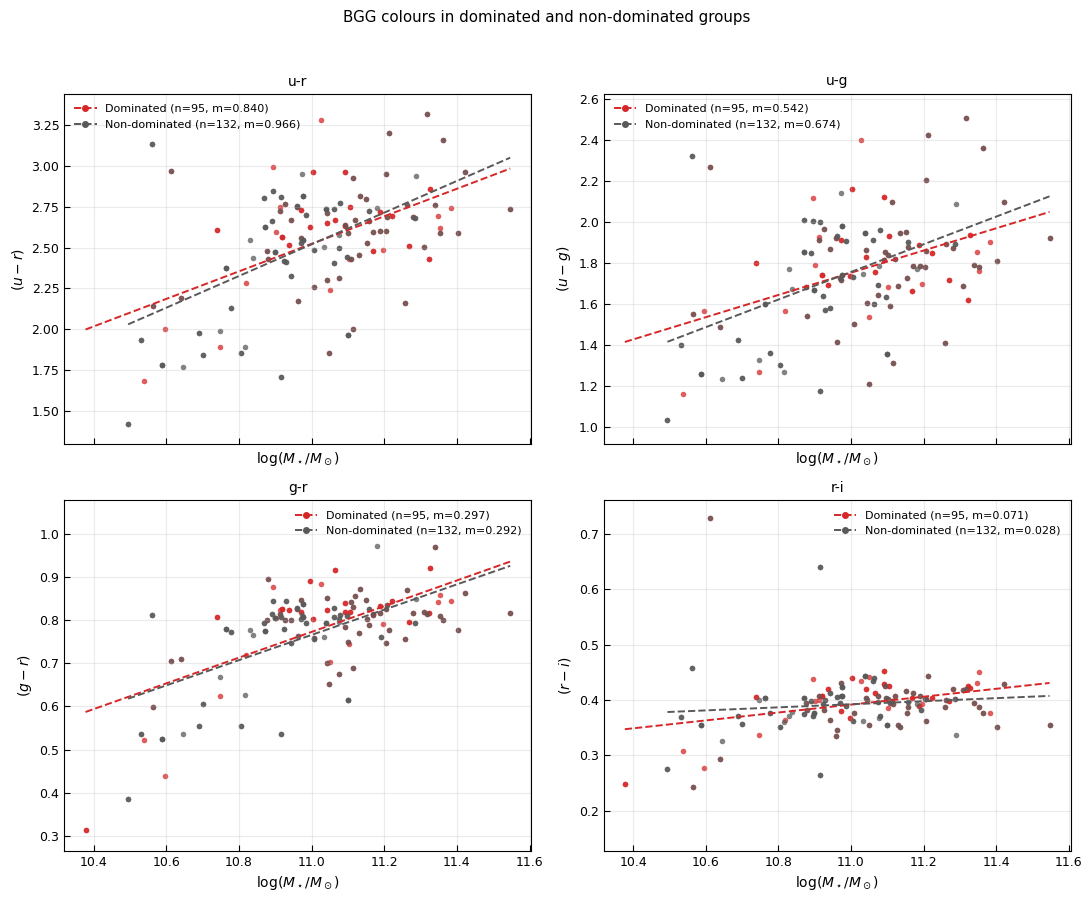

domination,Dominated,Non-dominated
catalogue,,
CG4,5,3
Control4B,19,81
Control4C,70,39
RG4,1,9


Each panel shows BGG colour versus stellar mass, split by whether the parent group is dominated or non-dominated.
The dashed lines are simple linear fits to guide the eye; the table gives the matched BGG counts by catalogue and domination class.


In [23]:
from matplotlib.lines import Line2D

if "bgg_mass_colour" not in globals():
    subsample_keys = ["CG4_Gals", "Control4B_Gals", "Control4C_Gals", "RG4_Gals"]
    catalogue_labels = {
        "CG4_Gals": "CG4",
        "Control4B_Gals": "Control4B",
        "Control4C_Gals": "Control4C",
        "RG4_Gals": "RG4",
    }

    sdss_bgg = sample["SDSS"].copy()
    sdss_bgg["_objid"] = _as_int(sdss_bgg["objid"])
    for column in ["u_obs", "g_obs", "r_obs", "i_obs"]:
        sdss_bgg[column] = pd.to_numeric(sdss_bgg[column], errors="coerce")

    sdss_bgg["u_r"] = sdss_bgg["u_obs"] - sdss_bgg["r_obs"]
    sdss_bgg["u_g"] = sdss_bgg["u_obs"] - sdss_bgg["g_obs"]
    sdss_bgg["g_r"] = sdss_bgg["g_obs"] - sdss_bgg["r_obs"]
    sdss_bgg["r_i"] = sdss_bgg["r_obs"] - sdss_bgg["i_obs"]
    sdss_bgg_lookup = sdss_bgg[["_objid", "u_r", "u_g", "g_r", "r_i"]].drop_duplicates("_objid")

    bgg_frames = []
    for key in subsample_keys:
        sub = sample[key].copy()
        sub["_objid"] = _as_int(sub["objid"])
        sub["lgm"] = pd.to_numeric(sub["lgm"], errors="coerce")
        merged = sub[["Group", "rank_M", "lgm", "is_dominated", "_objid"]].merge(sdss_bgg_lookup, on="_objid", how="inner")
        merged = merged.loc[(merged["rank_M"] == 1) & np.isfinite(merged["lgm"])].copy()
        dominated_flag = pd.to_numeric(merged["is_dominated"], errors="coerce").fillna(0).astype(int).astype(bool)
        merged["is_dominated"] = dominated_flag
        merged["domination"] = np.where(dominated_flag, "Dominated", "Non-dominated")
        merged["catalogue"] = catalogue_labels[key]
        bgg_frames.append(merged)

    bgg_mass_colour = pd.concat(bgg_frames, ignore_index=True)

colour_specs = [
    ("u_r", r"$(u-r)$", "u-r"),
    ("u_g", r"$(u-g)$", "u-g"),
    ("g_r", r"$(g-r)$", "g-r"),
    ("r_i", r"$(r-i)$", "r-i"),
]
palette = {
    "Dominated": "C3",
    "Non-dominated": "0.35",
}
legend_order = ["Dominated", "Non-dominated"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

for ax, (colour_key, colour_label, title) in zip(axes, colour_specs):
    panel = bgg_mass_colour[["lgm", colour_key, "domination"]].dropna().copy()
    if panel.empty:
        ax.set_visible(False)
        continue

    slope_by_group = {}
    count_by_group = {}

    for label in legend_order:
        group = panel.loc[panel["domination"] == label].sort_values("lgm")
        if group.empty:
            continue

        count_by_group[label] = len(group)
        ax.scatter(
            group["lgm"],
            group[colour_key],
            s=16,
            color=palette[label],
            alpha=0.75,
            linewidths=0,
            rasterized=True,
        )

        if len(group) >= 2:
            slope, intercept = np.polyfit(group["lgm"], group[colour_key], deg=1)
            slope_by_group[label] = slope
            x_fit = np.linspace(group["lgm"].min(), group["lgm"].max(), 100)
            ax.plot(
                x_fit,
                slope * x_fit + intercept,
                linestyle="--",
                linewidth=1.4,
                color=palette[label],
            )

    handles = []
    for label in legend_order:
        if label not in count_by_group:
            continue
        slope_text = f", m={slope_by_group[label]:.3f}" if label in slope_by_group else ""
        handles.append(
            Line2D(
                [0],
                [0],
                color=palette[label],
                linestyle="--",
                linewidth=1.4,
                marker="o",
                markerfacecolor=palette[label],
                markeredgecolor=palette[label],
                markersize=4,
                label=f"{label} (n={count_by_group[label]}{slope_text})",
            )
        )

    ax.set_title(title)
    ax.set_xlabel(r"$\log(M_\star/M_\odot)$")
    ax.set_ylabel(colour_label)
    ax.grid(alpha=0.25)
    if handles:
        ax.legend(handles=handles, frameon=False, fontsize=8, loc="best")

    y_lo, y_hi = panel[colour_key].quantile([0.01, 0.99])
    ax.set_ylim(y_lo - 0.12, y_hi + 0.12)

fig.suptitle("BGG colours in dominated and non-dominated groups", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

counts_by_domination = (
    bgg_mass_colour.groupby(["catalogue", "domination"], sort=False)
    .size()
    .unstack(fill_value=0)
)
display(counts_by_domination)
print("Each panel shows BGG colour versus stellar mass, split by whether the parent group is dominated or non-dominated.")
print("The dashed lines are simple linear fits to guide the eye; the table gives the matched BGG counts by catalogue and domination class.")



In [24]:
from scipy import stats
import statsmodels.formula.api as smf

if "bgg_mass_colour" not in globals():
    raise RuntimeError("Run the BGG dominated/non-dominated plot cell first so bgg_mass_colour is available.")

colour_specs = [
    ("u_r", "u-r"),
    ("u_g", "u-g"),
    ("g_r", "g-r"),
    ("r_i", "r-i"),
]


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running = 0.0
    m = len(p_values)

    for rank, idx in enumerate(order):
        candidate = min(1.0, (m - rank) * p_values[idx])
        running = max(running, candidate)
        adjusted[idx] = running

    return adjusted


mass_rows = []
for label in ["Dominated", "Non-dominated"]:
    group = bgg_mass_colour.loc[bgg_mass_colour["domination"] == label, "lgm"].dropna()
    mass_rows.append(
        {
            "group": label,
            "n_bgg": len(group),
            "median_logM": group.median(),
            "mean_logM": group.mean(),
        }
    )

mass_summary = pd.DataFrame(mass_rows)
dominated_mass = bgg_mass_colour.loc[bgg_mass_colour["domination"] == "Dominated", "lgm"].dropna()
non_dominated_mass = bgg_mass_colour.loc[bgg_mass_colour["domination"] == "Non-dominated", "lgm"].dropna()
mass_test = stats.mannwhitneyu(dominated_mass, non_dominated_mass, alternative="two-sided", method="asymptotic")

raw_rows = []
raw_p_values = []
for colour_key, colour_label in colour_specs:
    panel = bgg_mass_colour[[colour_key, "domination"]].dropna().copy()
    dominated = panel.loc[panel["domination"] == "Dominated", colour_key].to_numpy()
    non_dominated = panel.loc[panel["domination"] == "Non-dominated", colour_key].to_numpy()
    test = stats.mannwhitneyu(dominated, non_dominated, alternative="two-sided", method="asymptotic")

    raw_rows.append(
        {
            "colour": colour_label,
            "median_dominated": np.median(dominated),
            "median_non_dominated": np.median(non_dominated),
            "delta_median": np.median(dominated) - np.median(non_dominated),
            "mean_dominated": np.mean(dominated),
            "mean_non_dominated": np.mean(non_dominated),
            "delta_mean": np.mean(dominated) - np.mean(non_dominated),
            "p_raw": test.pvalue,
        }
    )
    raw_p_values.append(test.pvalue)

raw_summary = pd.DataFrame(raw_rows)
raw_summary["p_holm"] = holm_adjust(raw_p_values)
raw_summary["significant"] = np.where(raw_summary["p_holm"] < 0.05, "yes", "no")

adjusted_rows = []
offset_p_values = []
median_lgm_reference = bgg_mass_colour["lgm"].median()

for colour_key, colour_label in colour_specs:
    panel = bgg_mass_colour[["lgm", colour_key, "is_dominated"]].dropna().copy()
    panel["dominated"] = panel["is_dominated"].astype(int)
    model = smf.ols(f"{colour_key} ~ lgm * dominated", data=panel).fit(cov_type="HC3")

    params = model.params
    cov = model.cov_params()
    slope_non_dominated = params.get("lgm", 0.0)
    slope_dominated = slope_non_dominated + params.get("lgm:dominated", 0.0)
    slope_diff_p = model.pvalues.get("lgm:dominated", np.nan)

    names = list(params.index)
    weights = np.zeros(len(names))
    for index, name in enumerate(names):
        if name == "dominated":
            weights[index] = 1.0
        elif name == "lgm:dominated":
            weights[index] = median_lgm_reference

    offset = float(weights @ params.to_numpy())
    offset_se = float(np.sqrt(weights @ cov.to_numpy() @ weights))
    offset_z = offset / offset_se if offset_se > 0 else np.nan
    offset_p = 2 * stats.norm.sf(abs(offset_z)) if np.isfinite(offset_z) else np.nan
    offset_ci_low = offset - 1.96 * offset_se
    offset_ci_high = offset + 1.96 * offset_se

    adjusted_rows.append(
        {
            "colour": colour_label,
            "slope_non_dominated": slope_non_dominated,
            "slope_dominated": slope_dominated,
            "slope_diff_p": slope_diff_p,
            "delta_at_median_logM": offset,
            "delta_ci_low": offset_ci_low,
            "delta_ci_high": offset_ci_high,
            "offset_p": offset_p,
        }
    )
    offset_p_values.append(offset_p)

adjusted_summary = pd.DataFrame(adjusted_rows)
adjusted_summary["offset_p_holm"] = holm_adjust(offset_p_values)
adjusted_summary["significant_offset"] = np.where(adjusted_summary["offset_p_holm"] < 0.05, "yes", "no")

print("BGG stellar-mass distributions")
display(mass_summary.round({"median_logM": 4, "mean_logM": 4}))
print(f"Dominated BGGs are more massive in the matched sample: two-sided Mann-Whitney p = {mass_test.pvalue:.4g}.")
print()
print("Raw colour comparison (dominated minus non-dominated)")
display(
    raw_summary.round(
        {
            "median_dominated": 4,
            "median_non_dominated": 4,
            "delta_median": 4,
            "mean_dominated": 4,
            "mean_non_dominated": 4,
            "delta_mean": 4,
            "p_raw": 4,
            "p_holm": 4,
        }
    )
)
print()
print(f"Mass-adjusted comparison from HC3-robust ANCOVA at log(M_star/M_sun) = {median_lgm_reference:.4f}")
display(
    adjusted_summary.round(
        {
            "slope_non_dominated": 4,
            "slope_dominated": 4,
            "slope_diff_p": 4,
            "delta_at_median_logM": 4,
            "delta_ci_low": 4,
            "delta_ci_high": 4,
            "offset_p": 4,
            "offset_p_holm": 4,
        }
    )
)

significant_raw = raw_summary.loc[raw_summary["p_holm"] < 0.05, "colour"].tolist()
significant_adjusted = adjusted_summary.loc[adjusted_summary["offset_p_holm"] < 0.05, "colour"].tolist()
raw_text = ", ".join(significant_raw) if significant_raw else "none"
adjusted_text = ", ".join(significant_adjusted) if significant_adjusted else "none"

print(f"After Holm correction across the four colours, the raw dominated vs non-dominated difference is significant for: {raw_text}.")
print(f"After controlling for stellar mass, the dominated vs non-dominated colour offset is significant for: {adjusted_text}.")
print("A positive delta means dominated-group BGGs are redder than non-dominated-group BGGs.")



BGG stellar-mass distributions


,group,n_bgg,median_logM,mean_logM
0,Dominated,95,11.0920,11.0666
1,Non-dominated,132,10.9758,10.9808


Dominated BGGs are more massive in the matched sample: two-sided Mann-Whitney p = 0.0007319.

Raw colour comparison (dominated minus non-dominated)


,colour,median_dominated,median_non_dominated,delta_median,mean_dominated,mean_non_dominated,delta_mean,p_raw,p_holm,significant
0,u-r,2.6262,2.5543,0.0719,2.5787,2.5013,0.0774,0.1002,0.2003,no
1,u-g,1.7998,1.7566,0.0432,1.7865,1.7414,0.0451,0.2408,0.2408,no
2,g-r,0.8156,0.7949,0.0208,0.7922,0.7599,0.0323,0.0004,0.0016,yes
3,r-i,0.4024,0.3940,0.0085,0.3964,0.3917,0.0047,0.0251,0.0754,no



Mass-adjusted comparison from HC3-robust ANCOVA at log(M_star/M_sun) = 11.0424


,colour,slope_non_dominated,slope_dominated,slope_diff_p,delta_at_median_logM,delta_ci_low,delta_ci_high,offset_p,offset_p_holm,significant_offset
0,u-r,0.9663,0.8397,0.6650,-0.0024,-0.0896,0.0848,0.9574,1.0,no
1,u-g,0.6743,0.5422,0.5574,-0.0095,-0.0832,0.0641,0.7997,1.0,no
2,g-r,0.2920,0.2975,0.9502,0.0072,-0.0163,0.0306,0.5494,1.0,no
3,r-i,0.0277,0.0714,0.4553,0.0013,-0.0137,0.0163,0.8671,1.0,no


After Holm correction across the four colours, the raw dominated vs non-dominated difference is significant for: g-r.
After controlling for stellar mass, the dominated vs non-dominated colour offset is significant for: none.
A positive delta means dominated-group BGGs are redder than non-dominated-group BGGs.


In [25]:
import textwrap


def _join_items(values):
    cleaned = []
    for value in values:
        if pd.isna(value):
            continue
        text = str(value).strip()
        if not text or text in cleaned:
            continue
        cleaned.append(text)

    if not cleaned:
        return "none"
    if len(cleaned) == 1:
        return cleaned[0]
    if len(cleaned) == 2:
        return f"{cleaned[0]} and {cleaned[1]}"
    return ", ".join(cleaned[:-1]) + f", and {cleaned[-1]}"


def _is_significant(series):
    lowered = series.astype(str).str.lower()
    return lowered.isin(["true", "1", "yes"])


summary_parts = []
missing_sections = []

if {"global_summary", "pairwise_summary"}.issubset(globals()):
    global_panel = global_summary.copy()
    global_panel["pvalue"] = pd.to_numeric(global_panel["pvalue"], errors="coerce")
    global_sig = global_panel.loc[global_panel["pvalue"] < 0.05, "colour"].tolist()

    pairwise_sig = pairwise_summary.loc[
        _is_significant(pairwise_summary["significant_0.05"]),
        ["colour", "comparison"],
    ].copy()
    if global_sig:
        text = f"In the catalogue colour-mass relations, global slope differences are significant in {_join_items(global_sig)}"
    else:
        text = "In the catalogue colour-mass relations, no global slope difference is significant"

    if pairwise_sig.empty:
        text += "; no pairwise CG4-versus-other slope difference survives Holm correction."
    else:
        pieces = []
        for colour, frame in pairwise_sig.groupby("colour", sort=False):
            targets = [comparison.split(">")[-1].strip() for comparison in frame["comparison"]]
            pieces.append(f"{colour} (CG4 steeper than {_join_items(targets)})")
        text += f"; after Holm correction, pairwise significance remains only in {_join_items(pieces)}."

    summary_parts.append(text)
else:
    missing_sections.append("catalogue colour-mass slope tests")

if "correlation_summary" in globals():
    correlation_panel = correlation_summary.copy()
    pearson_all = correlation_panel.loc[
        (correlation_panel["sample"] == "All")
        & (pd.to_numeric(correlation_panel["pearson_p"], errors="coerce") < 0.05),
        "colour",
    ].tolist()
    spearman_all = correlation_panel.loc[
        (correlation_panel["sample"] == "All")
        & (pd.to_numeric(correlation_panel["spearman_p"], errors="coerce") < 0.05),
        "colour",
    ].tolist()

    catalogue_pieces = []
    for sample_label in ["CG4", "Control4B", "Control4C", "RG4"]:
        methods = []
        pearson_sig = correlation_panel.loc[
            (correlation_panel["sample"] == sample_label)
            & (pd.to_numeric(correlation_panel["pearson_p"], errors="coerce") < 0.05),
            "colour",
        ].tolist()
        spearman_sig = correlation_panel.loc[
            (correlation_panel["sample"] == sample_label)
            & (pd.to_numeric(correlation_panel["spearman_p"], errors="coerce") < 0.05),
            "colour",
        ].tolist()
        if pearson_sig:
            methods.append(f"Pearson in {_join_items(pearson_sig)}")
        if spearman_sig:
            methods.append(f"Spearman in {_join_items(spearman_sig)}")
        if methods:
            catalogue_pieces.append(f"{sample_label} ({'; '.join(methods)})")

    text = "BGG colour and mean satellite colour are significantly correlated in the full sample"
    if pearson_all and spearman_all and set(pearson_all) == set(spearman_all):
        text += f" for {_join_items(pearson_all)} in both Pearson and Spearman tests"
    elif pearson_all or spearman_all:
        method_bits = []
        if pearson_all:
            method_bits.append(f"Pearson in {_join_items(pearson_all)}")
        if spearman_all:
            method_bits.append(f"Spearman in {_join_items(spearman_all)}")
        text += " with " + " and ".join(method_bits)
    text += "."

    if catalogue_pieces:
        text += " Among individual catalogues, significant correlations are found in " + "; ".join(catalogue_pieces) + "."

    summary_parts.append(text)
else:
    missing_sections.append("BGG-satellite correlation tests")

if "slope_test_summary" in globals():
    slope_sig = slope_test_summary.loc[
        _is_significant(slope_test_summary["significant_0.05"]),
        ["colour", "comparison"],
    ].copy()
    if slope_sig.empty:
        summary_parts.append(
            "The slope linking BGG colour to mean satellite colour in CG4 is not significantly different from any control sample in any of the four colours."
        )
    else:
        pieces = []
        for colour, frame in slope_sig.groupby("colour", sort=False):
            pieces.append(f"{colour} versus {_join_items(frame['comparison'])}")
        summary_parts.append("The CG4 BGG-to-satellite slope differs significantly from the controls in " + _join_items(pieces) + ".")
else:
    missing_sections.append("CG4 versus control BGG-satellite slope tests")

if "satellite_colour_summary" in globals():
    satellite_panel = satellite_colour_summary.copy()
    sig_offsets = satellite_panel.loc[_is_significant(satellite_panel["difference_significant_0.05"])].copy()
    sig_interactions = satellite_panel.loc[
        _is_significant(satellite_panel["interaction_significant_0.05"]),
        "colour",
    ].tolist()

    if sig_offsets.empty:
        text = "At fixed stellar mass, compact-group satellites do not show a significant colour offset relative to ordinary-group satellites"
    else:
        pieces = []
        for row in sig_offsets.itertuples():
            delta = float(row.compact_minus_ordinary_at_ref_mass)
            direction = "redder" if delta > 0 else "bluer"
            pieces.append(f"{row.colour} ({abs(delta):.3f} mag {direction})")
        text = "At fixed stellar mass, compact-group satellites differ significantly from ordinary-group satellites in " + _join_items(pieces)

    if sig_interactions:
        text += f", and the colour-mass slope itself differs in {_join_items(sig_interactions)}"
    text += "."
    summary_parts.append(text)
else:
    missing_sections.append("compact versus ordinary satellite comparison")

if {"raw_summary", "adjusted_summary", "mass_summary", "mass_test"}.issubset(globals()):
    mass_panel = mass_summary.copy()
    dom_mass = pd.to_numeric(
        mass_panel.loc[mass_panel["group"] == "Dominated", "median_logM"],
        errors="coerce",
    )
    non_dom_mass = pd.to_numeric(
        mass_panel.loc[mass_panel["group"] == "Non-dominated", "median_logM"],
        errors="coerce",
    )
    mass_pvalue = float(mass_test.pvalue)

    if len(dom_mass) and len(non_dom_mass) and mass_pvalue < 0.05:
        if dom_mass.iloc[0] > non_dom_mass.iloc[0]:
            text = "Dominated-group BGGs are significantly more massive than non-dominated-group BGGs"
        elif dom_mass.iloc[0] < non_dom_mass.iloc[0]:
            text = "Dominated-group BGGs are significantly less massive than non-dominated-group BGGs"
        else:
            text = "Dominated-group and non-dominated-group BGGs have significantly different stellar masses"
    else:
        text = "Dominated-group and non-dominated-group BGGs do not show a significant stellar-mass difference"

    raw_sig = raw_summary.loc[_is_significant(raw_summary["significant"]), "colour"].tolist()
    adjusted_sig = adjusted_summary.loc[_is_significant(adjusted_summary["significant_offset"]), "colour"].tolist()

    if raw_sig:
        text += f"; in the raw colour comparison, {_join_items(raw_sig)} is significant after Holm correction"
    else:
        text += "; no raw colour difference is significant after Holm correction"

    if adjusted_sig:
        text += f", and after controlling for stellar mass the remaining significant offset is in {_join_items(adjusted_sig)}."
    else:
        text += ", but no colour offset remains significant after controlling for stellar mass."

    summary_parts.append(text)
else:
    missing_sections.append("dominated versus non-dominated BGG comparison")

significance_synthesis = " ".join(summary_parts)
print(textwrap.fill(significance_synthesis, width=120))

if missing_sections:
    print()
    print(
        "Analyses not yet available in memory: "
        + "; ".join(missing_sections)
        + ". Run those result cells first and rerun this synthesis cell."
    )



In the catalogue colour-mass relations, global slope differences are significant in u-r, u-g, g-r, and r-i; after Holm
correction, pairwise significance remains only in u-r (CG4 steeper than Control4C and SDSS) and u-g (CG4 steeper than
Control4C and SDSS). BGG colour and mean satellite colour are significantly correlated in the full sample for u-r, u-g,
g-r, and r-i in both Pearson and Spearman tests. Among individual catalogues, significant correlations are found in
Control4B (Pearson in u-r and g-r; Spearman in g-r); Control4C (Pearson in u-r, u-g, and g-r; Spearman in u-r, u-g, g-r,
and r-i); RG4 (Pearson in u-r and g-r). The slope linking BGG colour to mean satellite colour in CG4 is not
significantly different from any control sample in any of the four colours. At fixed stellar mass, compact-group
satellites differ significantly from ordinary-group satellites in u-r (0.124 mag bluer) and u-g (0.106 mag bluer), and
the colour-mass slope itself differs in u-r, u-g, and g-r. Dominat